## 授權與來源（License & Attribution）

本課程自編／改編的程式與文字：Copyright 2026 leonjyentub；Apache License 2.0（`../LICENSE`）。
教學概念與來源參照：Aurélien Géron, `ageron/handson-mlp` Ch.11 最佳化與正則化，上游 Apache-2.0，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
本檔改編／創作說明：依原書概念另編可於 CPU 執行的小型機制實驗、示範圖表與中文教學解釋；不等同於完整上游實驗，亦不表示每段程式均直接複製上游。
詳細對照：`../SOURCES.md`；授權及署名：`../THIRD_PARTY_NOTICES.md`。
其他第三方資料、圖片及模型權利按各自來源處理，不包含在本課程程式授權中。

# 13｜深層神經網路訓練_最佳化與正則化

在同一個狹長損失面比較一般梯度下降與 Momentum。

對應 `slides/13_深層神經網路訓練_最佳化與正則化.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/11_training_deep_neural_networks.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Momentum、Adam、Learning Rate Scheduling、Regularization。

- `MachineLearning2025/01_batchgradientDescent.ipynb；02_Regularization_Regression.ipynb；02_Polynomial_Regression_Early_stopping.ipynb`，固定 commit `3da2cb56b9efd17d7cd34602589f392554b40603`。
- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
A = np.diag([1.0, 30.0])
def optimize(momentum=0.0, eta=0.035, steps=80):
    theta = np.array([4.0, 1.5]); velocity = np.zeros(2); losses = []
    for _ in range(steps):
        losses.append(0.5 * theta @ A @ theta)
        grad = A @ theta
        velocity = momentum * velocity + grad
        theta -= eta * velocity
    return np.array(losses), theta

plain_loss, plain_theta = optimize(momentum=0.0)
mom_loss, mom_theta = optimize(momentum=0.8)
pd.DataFrame({'method': ['GD', 'Momentum'], 'final_loss': [plain_loss[-1], mom_loss[-1]],
              'theta_0': [plain_theta[0], mom_theta[0]], 'theta_1': [plain_theta[1], mom_theta[1]]})

,method,final_loss,theta_0,theta_1
0,GD,2.873462e-02,0.231337,1.240771e-104
1,Momentum,7.739928e-07,0.000611,-2.046445e-04


## 執行結果圖

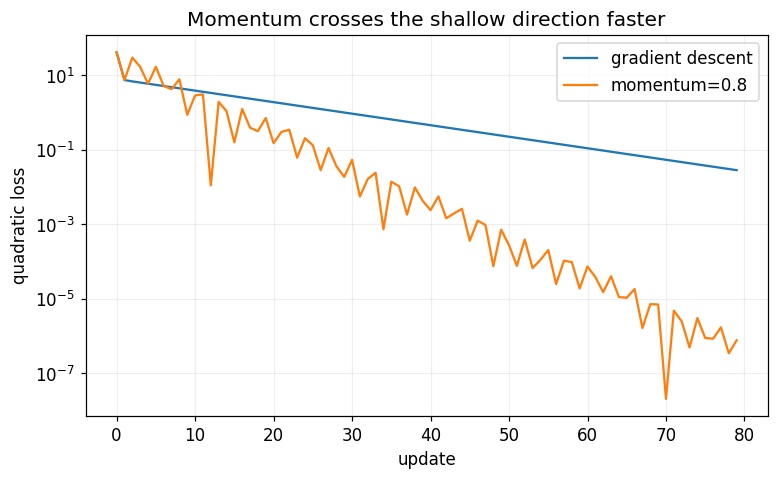

In [3]:
plt.semilogy(plain_loss, label='gradient descent')
plt.semilogy(mom_loss, label='momentum=0.8')
plt.xlabel('update'); plt.ylabel('quadratic loss'); plt.title('Momentum crosses the shallow direction faster')
plt.legend()
savefig('13_optimizer_regularization_demo')
report('optimizer_regularization', {'gd_final_loss': plain_loss[-1], 'momentum_final_loss': mom_loss[-1]})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。